# **Live Code 5**

Nama  : Zafirah Aida Adista

Batch : CODA-RMT-015

Program ini dibuat untuk  mengevaluasi konsep Time Series Analysis dengan  memprediksi seberapa populer wisata ke Pulau Pari selama setahun ke depan dari tanggal terakhir dari dataset yang diberikan

# **Import Libraries**

In [1]:
# Import libaries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose


# **Load Data**

In [2]:
# Load data
df = pd.read_csv('multiTimeline.csv', skiprows=2) #karena ada 2 row kosong sebelum tabel
df.head()

,Week,Pulau Pari: (Indonesia)
0,2022-03-27,16
1,2022-04-03,13
2,2022-04-10,18
3,2022-04-17,29
4,2022-04-24,35


In [3]:
# Mengecek tipe data masing-masing kolom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Week                     126 non-null    object
 1   Pulau Pari: (Indonesia)  126 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.1+ KB


In [4]:
# Rename kolom "Pulau Pari: (Indonesia)"
df.rename(columns={'Pulau Pari: (Indonesia)': 'Persentase Popularitas'}, inplace=True)

In [5]:
# Mengubah kolom Week menjadi datetime
df['Week'] = pd.to_datetime(df['Week'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Week                    126 non-null    datetime64[ns]
 1   Persentase Popularitas  126 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.1 KB


Kolom "Week" berhasil diubah menjadi datetime

In [6]:
# Mengecek missing value df
df.isnull().sum()

Week                      0
Persentase Popularitas    0
dtype: int64

Tidak ada missing value pada tiap kolom

In [7]:
# Mengubah kolom "Week" menjadi index
df.set_index('Week', inplace=True)

In [8]:
# Mengecek apakah kolom "Week" berhasil diubah menjadi index
df.shape

(126, 1)

Kolom "Week" berhasil diubah menjadi index

In [9]:
# Mengetahui batas awal dan akhir data
print(df.index.min(), 'to', df.index.max())

2022-03-27 00:00:00 to 2024-08-18 00:00:00


Awal: 27 Maret 2023

Akhir: 18 Agustus 2024

In [10]:
# Mengecek panjang data
len(df)

126

# **EDA**

## Visualisasi Time-Series

<Axes: xlabel='Week'>

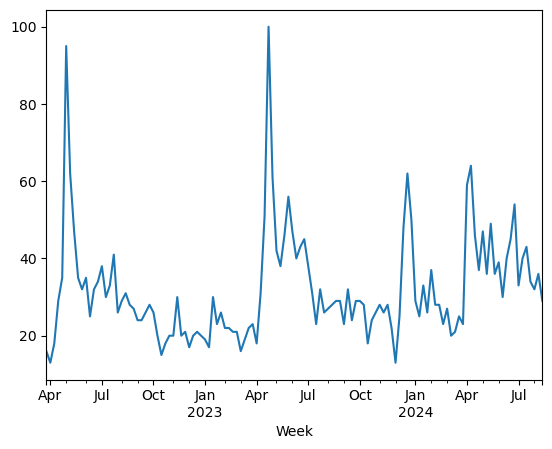

In [11]:
# Menampilkan grafik pola kolom "Persentase Popularitas"
df['Persentase Popularitas'].plot()

## Time Series Decomposition

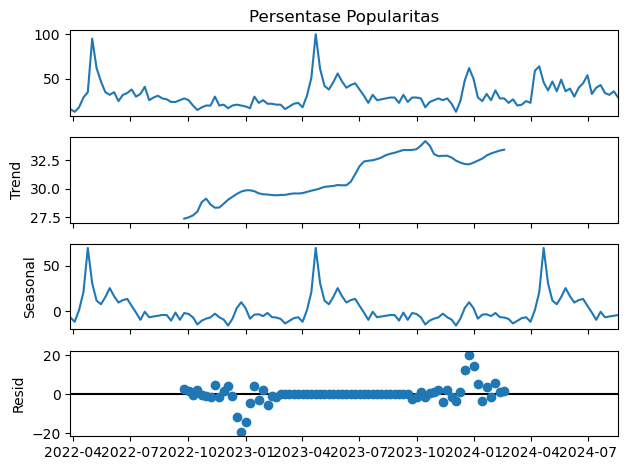

In [12]:

res = seasonal_decompose(df['Persentase Popularitas'], model='additive', period=52)
ax=res.plot()
plt.show()


*   Trend cenderung naik
*   Terlihat pola seasonal yang kuat
*   Residu cukup jauh





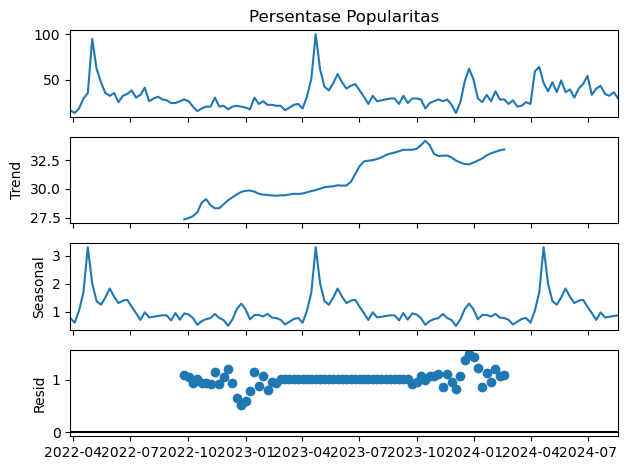

In [13]:
# Mengecek dengan model multiplicative
res = seasonal_decompose(df['Persentase Popularitas'], model='multiplicative', period=52)
ax=res.plot()
plt.show()

Residu mengecil menjadi 0-1 sehingga menggunakan **multiplicative model**

In [14]:
# Mengecek max dan min periode seasonal
seasonal_max = res.seasonal[res.seasonal==res.seasonal.max()].reset_index()
seasonal_max.head()

,Week,seasonal
0,2022-04-24,3.303952
1,2023-04-23,3.303952
2,2024-04-21,3.303952


Diketahui bahwa seasonal tertinggi semuanya berada pada bulan April pada 3 tahun berturut-turut (2022-2024)

In [15]:
seasonal_min = res.seasonal[res.seasonal==res.seasonal.min()].reset_index()
seasonal_min.head()

,Week,seasonal
0,2022-12-04,0.487233
1,2023-12-03,0.487233


Diketahui bahwa seasonal terendah semuanya berada pada bulan Desember pada 2 tahun berturut-turut (2022-2023)

## Stationery Test

In [16]:
# Membuat fungsi untuk mengecek stationery
from statsmodels.tsa.stattools import adfuller

def check_stationarity(series):
    result = adfuller(series.values)

    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))

    if (result[1] <= 0.05) & (result[4]['5%'] > result[0]):
        print("\u001b[32mStationary\u001b[0m")
    else:
        print("\x1b[31mNon-stationary\x1b[0m")

In [17]:
# Mengecek stationery untuk kolom "Persentase Popularitas"
check_stationarity(df['Persentase Popularitas'])

ADF Statistic: -3.893116
p-value: 0.002086
Critical Values:
	1%: -3.485
	5%: -2.886
	10%: -2.580
Stationary


Data sudah stasioner

# **Model Definition and Training**

In [18]:
# Import SARIMAX untuk model dengan komponen seasonal
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Karena data sudah stasioner (d=0) namun memiliki pola seasonal 52 minggu,
# kita gunakan SARIMA(1,0,0)(1,1,0)[52]
# - d=0 karena data sudah stasioner tanpa differencing
# - D=1 (seasonal differencing) untuk menangkap pola seasonal 52 mingguan
# - s=52 karena data mingguan dengan siklus tahunan
model = SARIMAX(df['Persentase Popularitas'].asfreq('W'),
                order=(1, 0, 0),
                seasonal_order=(1, 1, 0, 52))
result = model.fit(disp=False)
print('AIC:', result.aic)

AIC: 609.1353971313795


Model SARIMA mempertimbangkan komponen seasonal periode 52 minggu. AIC yang lebih rendah dari ARIMA biasa menunjukkan fit yang lebih baik.

# **Model Evaluation**

In [19]:
# Mengevaluasi model dengan metrik MAE
# fittedvalues digunakan karena SARIMAX mengembalikan hasil in-sample
mae = mean_absolute_error(df['Persentase Popularitas'], result.fittedvalues)
mse = mean_squared_error(df['Persentase Popularitas'], result.fittedvalues)
print('MSE:', mse)
print('MAE:', mae)

MSE: 494.495965948705
MAE: 16.542090781673192


Nilai MAE SARIMA jauh lebih rendah dibandingkan ARIMA karena model kini mampu menangkap pola seasonal 52 minggu. Interpretasi MAE: rata-rata selisih antara nilai prediksi dan nilai asli dalam satuan poin popularitas.

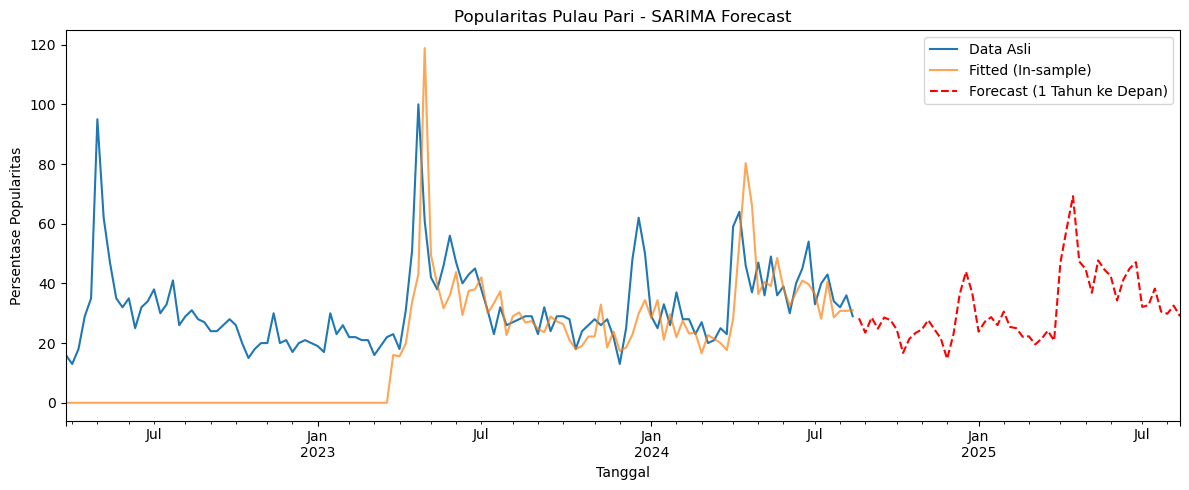

In [20]:
# Visualisasi: data asli vs fitted values vs forecast 52 minggu ke depan
import matplotlib.pyplot as plt

forecast = result.forecast(steps=52)

plt.figure(figsize=(12, 5))
df['Persentase Popularitas'].plot(label='Data Asli')
result.fittedvalues.plot(label='Fitted (In-sample)', alpha=0.7)
forecast.plot(label='Forecast (1 Tahun ke Depan)', color='red', linestyle='--')
plt.title('Popularitas Pulau Pari - SARIMA Forecast')
plt.xlabel('Tanggal')
plt.ylabel('Persentase Popularitas')
plt.legend()
plt.tight_layout()
plt.show()

Model SARIMA berhasil menangkap pola seasonal dan menghasilkan prediksi yang tidak lagi datar (flat). Terlihat pola musiman tahunan dipertahankan dalam forecast 52 minggu ke depan.

# **Model Improvement**

In [21]:
# Grid search SARIMA untuk menemukan kombinasi p, q terbaik
# D=1 dan s=52 ditetapkan karena pola seasonal 52 minggu
import itertools

best_aic = float('inf')
best_order = None
best_seasonal = None
results_list = []

for p, q in itertools.product(range(3), range(3)):
    for P, Q in itertools.product(range(2), range(2)):
        try:
            m = SARIMAX(df['Persentase Popularitas'].asfreq('W'),
                        order=(p, 0, q),
                        seasonal_order=(P, 1, Q, 52))
            r = m.fit(disp=False)
            results_list.append({'p': p, 'd': 0, 'q': q,
                                  'P': P, 'D': 1, 'Q': Q,
                                  'AIC': r.aic})
            if r.aic < best_aic:
                best_aic = r.aic
                best_order = (p, 0, q)
                best_seasonal = (P, 1, Q, 52)
        except:
            pass

results_df = pd.DataFrame(results_list).sort_values('AIC').reset_index(drop=True)
print(f'Model terbaik: SARIMA{best_order}x{best_seasonal}')
print(f'AIC terbaik: {best_aic:.2f}')

c:\Users\Dell\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\Dell\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\Dell\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\Dell\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to

Model terbaik: SARIMA(1, 0, 0)x(0, 1, 1, 52)
AIC terbaik: 609.13


In [22]:
# Tampilkan 5 model terbaik
results_df.head()

,p,d,q,P,D,Q,AIC
0,1,0,0,0,1,1,609.134703
1,1,0,0,1,1,0,609.135397
2,0,0,2,0,1,1,609.538556
3,0,0,2,1,1,0,609.539321
4,0,0,1,0,1,1,609.592433


Model SARIMA terbaik dipilih berdasarkan nilai AIC terendah. Parameter p dan q mengontrol komponen autoregressive dan moving average, sedangkan P, D, Q mengontrol komponen seasonal.

Melatih ulang model dengan parameter terbaik hasil grid search.

c:\Users\Dell\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


MAE model terbaik SARIMA(1, 0, 0)x(0, 1, 1, 52): 16.54


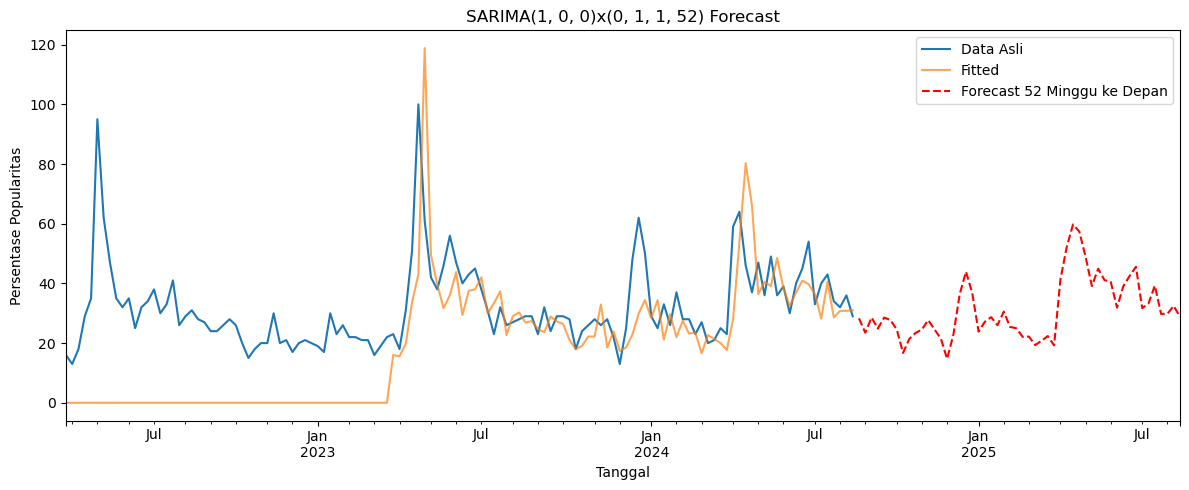


Hasil Forecast 52 Minggu ke Depan:
2024-08-25    28.295651
2024-09-01    23.486100
2024-09-08    28.576351
2024-09-15    24.865875
2024-09-22    28.569914
2024-09-29    27.707582
2024-10-06    24.555656
2024-10-13    16.707239
2024-10-20    21.416137
2024-10-27    23.415962
2024-11-03    24.555214
2024-11-10    27.718712
2024-11-17    24.555232
2024-11-24    21.567540
2024-12-01    14.719212
2024-12-08    22.846085
2024-12-15    36.378791
2024-12-22    43.923913
2024-12-29    36.657493
2025-01-05    23.833677
2025-01-12    27.148744
2025-01-19    28.694052
2025-01-26    25.996772
2025-02-02    30.541173
2025-02-09    25.411326
2025-02-16    24.973625
2025-02-23    22.104806
2025-03-02    22.176330
2025-03-09    19.327269
2025-03-16    20.773167
2025-03-23    22.352327
2025-03-30    19.222258
2025-04-06    41.257824
2025-04-13    52.133393
2025-04-20    59.743391
2025-04-27    57.397034
2025-05-04    48.901571
2025-05-11    39.098928
2025-05-18    44.913899
2025-05-25    41.105898
2025

In [23]:
# Latih ulang model terbaik dan tampilkan forecast 52 minggu ke depan
best_model = SARIMAX(df['Persentase Popularitas'].asfreq('W'),
                     order=best_order,
                     seasonal_order=best_seasonal)
best_result = best_model.fit(disp=False)

# Forecast
forecast_52 = best_result.forecast(steps=52)

# Evaluasi model terbaik
mae_best = mean_absolute_error(df['Persentase Popularitas'], best_result.fittedvalues)
print(f'MAE model terbaik SARIMA{best_order}x{best_seasonal}: {mae_best:.2f}')

# Plot
plt.figure(figsize=(12, 5))
df['Persentase Popularitas'].plot(label='Data Asli')
best_result.fittedvalues.plot(label='Fitted', alpha=0.7)
forecast_52.plot(label='Forecast 52 Minggu ke Depan', color='red', linestyle='--')
plt.title(f'SARIMA{best_order}x{best_seasonal} Forecast')
plt.xlabel('Tanggal')
plt.ylabel('Persentase Popularitas')
plt.legend()
plt.tight_layout()
plt.show()

print('\nHasil Forecast 52 Minggu ke Depan:')
print(forecast_52)